# Projeto - Sprint 8


## 1. - Introdução aos Datasets

### 1.1 - Importações

In [ ]:
# leitura bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
import numpy as np

In [ ]:
# leitura tabelas
visits = pd.read_csv('..\datasets\visits_log_us.csv')
orders = pd.read_csv('..\datasets\orders_log_us.csv')
costs = pd.read_csv('..\datasets\costs_us.csv')

### 1.2 - Primeiras impressões

#### 1.2.1 - Tabela visits


In [ ]:
# descoberta primeiras linhas
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [ ]:
# descoberta características df
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [ ]:
# descoberta detalhes df
visits.describe()

,Source Id,Uid
count,359400.000000,3.594000e+05
mean,3.750515,9.202557e+18
std,1.917116,5.298433e+18
min,1.000000,1.186350e+13
25%,3.000000,4.613407e+18
50%,4.000000,9.227413e+18
75%,5.000000,1.372824e+19
max,10.000000,1.844668e+19


A tabela visits não possui valores nulos, apresenta necessidade de conversão de tipo de dado para coluna End Ts e Start Ts e adoção do método snake_case para nomenclatura de colunas.

#### 1.2.2 - Tabela orders


In [ ]:
# descoberta primeiras linhas
orders.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [ ]:
# descoberta características df
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [ ]:
# descoberta detalhes df
orders.describe()

,Revenue,Uid
count,50415.000000,5.041500e+04
mean,4.999647,9.098161e+18
std,21.818359,5.285742e+18
min,0.000000,3.135781e+14
25%,1.220000,4.533567e+18
50%,2.500000,9.102274e+18
75%,4.890000,1.368290e+19
max,2633.280000,1.844617e+19


A tabela orders não apresenta valores nulos, demonstra necessidade de conversão de tipo de dado para coluna Buy Ts e adoção do método snake_case para nomenclatura de colunas.

#### 1.2.3 - Tabela costs


In [ ]:
# descoberta primeiras linhas
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [ ]:
# descoberta características df
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [ ]:
# descoberta detalhes df
costs.describe()

,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


A tabela orders não apresenta valores nulos, demonstra a necessidade de conversão de tipo de dado para a coluna dt.

## 2. - Pré Processamento de Dados

### 2.1 - Renomeando colunas

In [ ]:
# adoção snake_case df visits
visits.columns = (
    visits.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# adoção snake_case df orders
orders.columns = (
    orders.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# adoção snake_case df costs
costs.columns = (
    costs.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)


### 2.2 - Alterações de tipos de dado

In [ ]:
# correções e melhorias no df visits
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['device'] = visits['device'].astype('category')
visits['source_id'] = visits['source_id'].astype('category')

# correções e melhorias no df orders
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

# correções e melhorias no df costs
costs['dt'] = pd.to_datetime(costs['dt'])
costs['source_id'] = costs['source_id'].astype('category')

### 2.3 Validação Ausentes

In [ ]:
# validação nulos df visits
visits.isna().sum()

# validação nulos df orders
orders.isna().sum()

# validação nulos df costs
costs.isna().sum()

,0
source_id,0
dt,0
costs,0


### 2.4 - Validação Duplicados

In [ ]:
# validação duplicados df visits
visits.duplicated().sum()

# validação duplicados df orders
orders.duplicated().sum()

# validação duplicados df costs
costs.duplicated().sum()

np.int64(0)

### 2.5 - Criação colunas

In [ ]:
# criação colunas para os diferentes formatos temporais df visits
visits['session_date'] = visits['start_ts'].dt.date
visits['session_week'] = visits['start_ts'].dt.isocalendar().week
visits['session_month'] = visits['start_ts'].dt.month
visits['session_year'] = visits['start_ts'].dt.isocalendar().year
visits['session_month_year'] = visits['start_ts'].dt.to_period('M')

In [ ]:
# criação colunas para os diferentes formatos temporais df orders
orders['order_date'] = orders['buy_ts'].dt.date
orders['order_week'] = orders['buy_ts'].dt.isocalendar().week
orders['order_month'] = orders['buy_ts'].dt.month
orders['order_year'] = orders['buy_ts'].dt.isocalendar().year

In [ ]:
# criação colunas para os diferentes formatos temporais df costs
costs['week'] = costs['dt'].dt.isocalendar().week
costs['month'] = costs['dt'].dt.month
costs['year'] = costs['dt'].dt.isocalendar().year

## 3. - EDA

### 3.1 - Produto

#### 3.1.1 - Quantas pessoas usam-no cada dia, semana e mês?

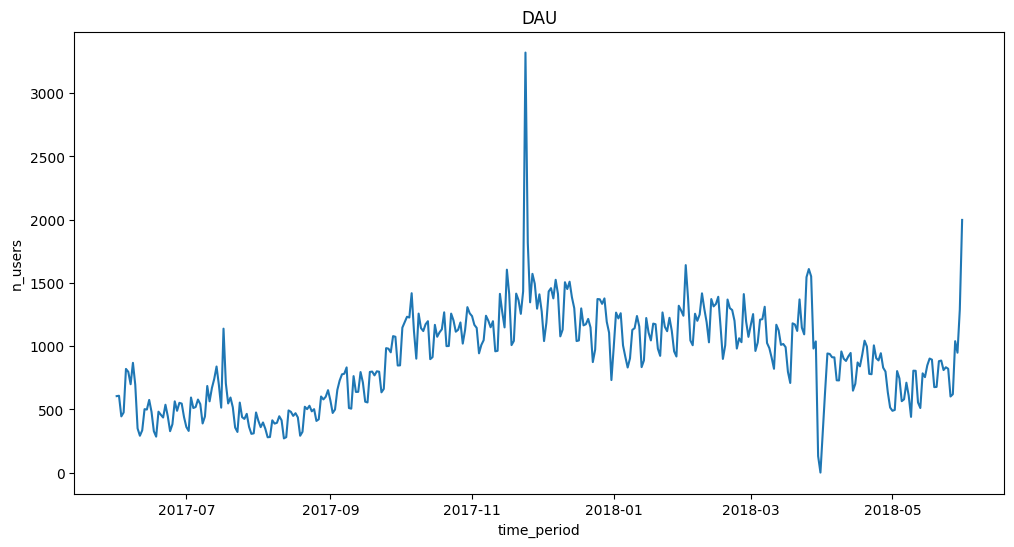

In [ ]:
# agrupamento do número de clientes por dias
dau = visits.groupby('session_date').agg({'uid': 'nunique'}).reset_index()

# convertendo a coluna de data para o formato datetime para melhor plotagem
dau['session_date'] = pd.to_datetime(dau['session_date'])

# gráfico DAU
plt.figure(figsize=(12, 6))
plt.title('DAU')
sns.lineplot(data=dau, x='session_date', y='uid')
plt.ylabel('n_users')
plt.xlabel('time_period')
plt.show()

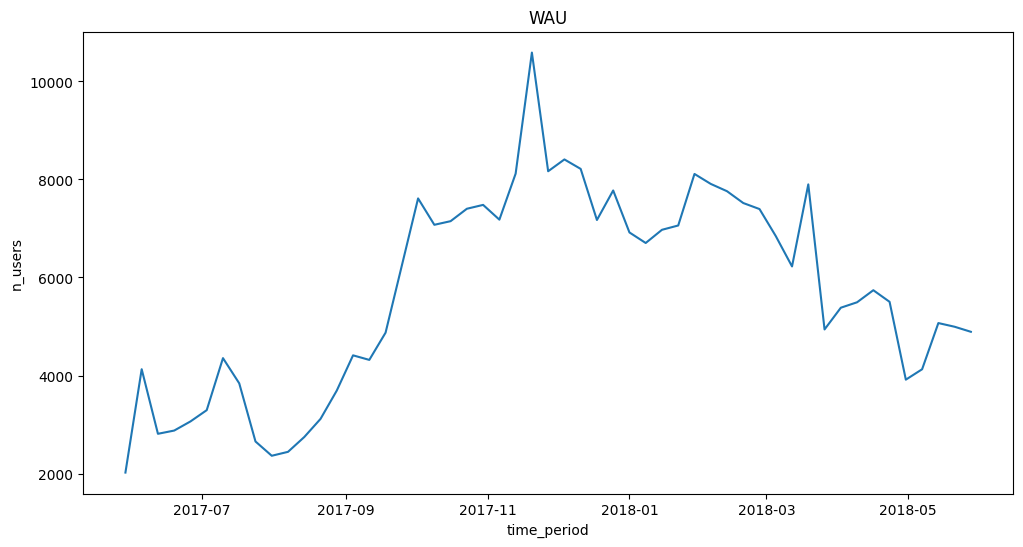

In [ ]:
# agrupamento do número de clientes por semanas
wau = visits.groupby(['session_year', 'session_week']).agg({'uid': 'nunique'}).reset_index()

# agrupando por período semanal
wau_plot_data = visits.groupby(visits['start_ts'].dt.to_period('W').dt.to_timestamp())['uid'].nunique().reset_index()

# gráfico WAU
plt.figure(figsize=(12, 6))
plt.title('WAU')
sns.lineplot(data=wau_plot_data, x='start_ts', y='uid')
plt.ylabel('n_users')
plt.xlabel('time_period')

plt.show()

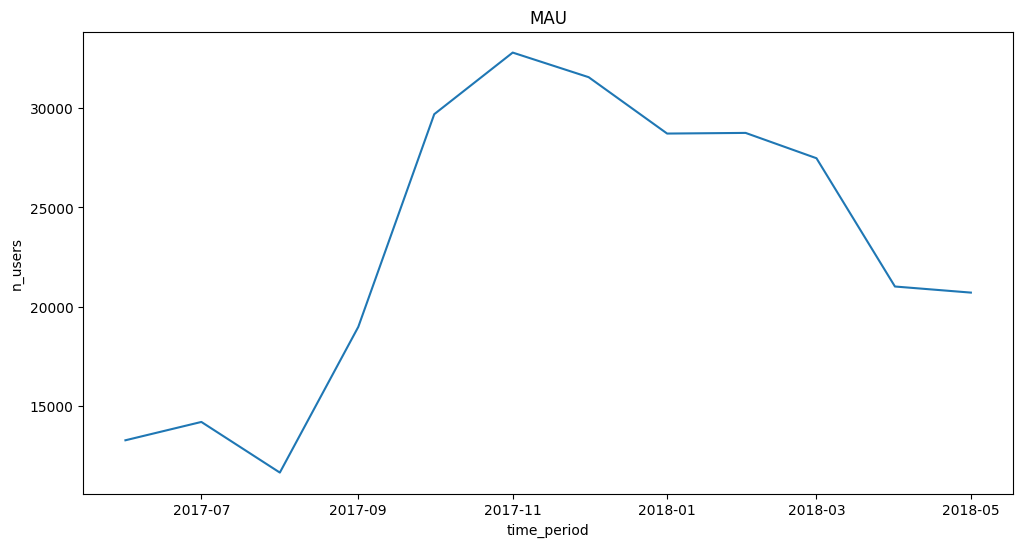

In [ ]:
# agrupamento do número de clientes por meses
mau = visits.groupby(['session_year' ,'session_month']).agg({'uid': 'nunique'}).reset_index()

# agrupando por período mensal
mau_plot = visits.groupby(visits['start_ts'].dt.to_period('M').dt.to_timestamp())['uid'].nunique().reset_index()

# gráfico MAU
plt.figure(figsize=(12, 6))
plt.title('MAU')
plt.xlabel('time_period')
plt.ylabel('n_users')
sns.lineplot(data=mau_plot, x='start_ts', y='uid')

plt.show()

In [ ]:
# descoberta média dau, wau e mau ao longo do período
print(f"Usuários Ativos Diários em média: {dau['uid'].mean():.0f}")
print(f"Usuários Ativos Semanais em média: {wau['uid'].mean():.0f}")
print(f"Usuários Ativos Mensais em média: {mau['uid'].mean():.0f}")

Usuários Ativos Diários em média: 908
Usuários Ativos Semanais em média: 5716
Usuários Ativos Mensais em média: 23228


A média de pessoas que usam o aplicativo diariamente é de aproximadamente 908 pessoas.

A média de pessoas que usam o aplicativo semanalmente é de aproximadamente 5716 pessoas.

A média de pessoas que usam o aplicativo mensalmente é de aproximadamente 23228 pessoas.

#### 3.1.2 - Quantas sessões ocorrem por dia?


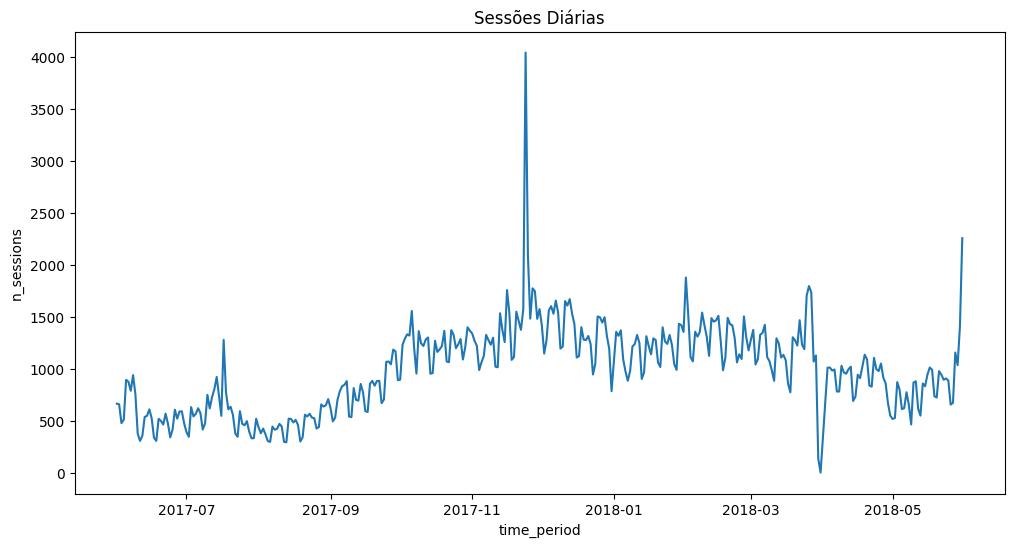

In [ ]:
# agrupamento do número de sessões por dia
sessions_per_day = visits.groupby('session_date').agg({'uid': 'count'}).reset_index()

# ajuste tipo de dado
sessions_per_day['session_date'] = pd.to_datetime(sessions_per_day['session_date'])

# gráfico número sessões dia
plt.figure(figsize=(12,6))
plt.title('Sessões Diárias')
sns.lineplot(data=sessions_per_day, x='session_date', y='uid')
plt.ylabel('n_sessions')
plt.xlabel('time_period')
plt.show()

In [ ]:
# descoberta de média de sessões diárias ao longo do período
print(f'O número médio de sessões diárias é {sessions_per_day['uid'].mean():.2f}')

O número médio de sessões diárias é 987.36


A média de sessões diárias é de aproximadamente 987.

#### 3.1.3 - Que comprimento tem cada sessão?


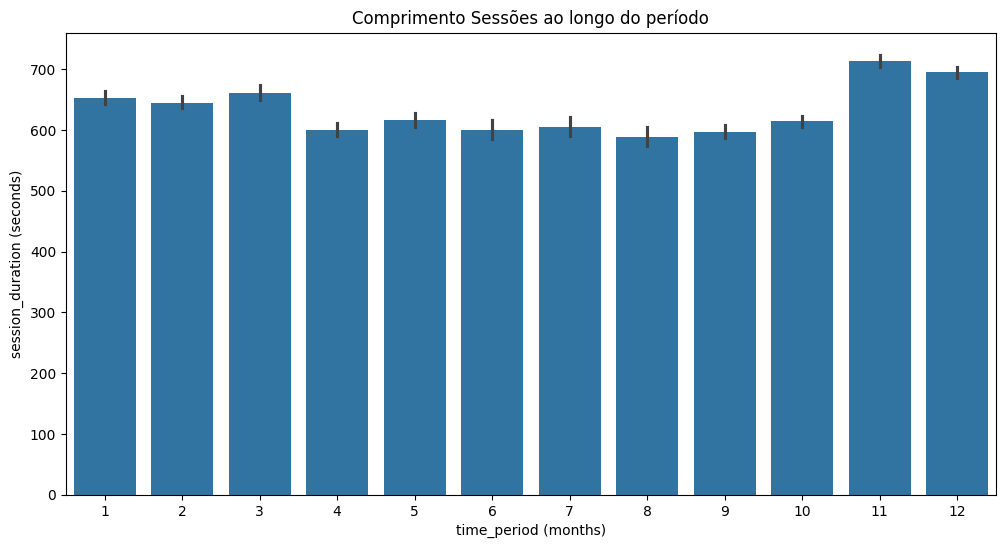

In [ ]:
# criação coluna duração em segundos cada sessão
visits['session_duration_seconds'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

# gráfico comprimento das sessões
plt.figure(figsize=(12,6))
plt.title('Comprimento Sessões ao longo do período')
sns.barplot(data=visits, x='session_month', y='session_duration_seconds')
plt.ylabel('session_duration (seconds)')
plt.xlabel('time_period (months)')
plt.show()

In [ ]:
# descoberta de média e mediana comprimento sessões ao longo do período
print(f'A média do comprimento das sessões é de {visits['session_duration_seconds'].mean():.2f} segundos')
print(f'A mediana do comprimento das sessões é de {visits['session_duration_seconds'].median():.2f} segundos')

A média do comprimento das sessões é de 643.51 segundos
A mediana do comprimento das sessões é de 300.00 segundos


Cada sessão realizada tem em média uma duração de cerca de 11 minutos.

Cada sessão realizada tem em sua mediana uma duração de cerca de 5 minutos.

#### 3.1.4 - Com que frequência os usuários voltam?


In [ ]:
# descoberta data primeira visita
first_visit = visits.groupby('uid')['session_date'].min().reset_index()

# renomeando colunas
first_visit.columns = ['uid', 'first_visit']

# criação coluna first_visit df visits
visits = pd.merge(visits, first_visit, on='uid')

# conversão tipo de dado
visits['first_visit'] = pd.to_datetime(visits['first_visit'])

# diferença entre qualquer visita e a primeira visita em dias
visits['visits_days_dif'] = (visits['start_ts'] - visits['first_visit']).dt.days

# descoberta média dias para retornar ao aplicativo por usuário
average_visits_dif = visits.groupby('uid').agg({'visits_days_dif': 'mean'}).reset_index()

# descoberta média entre todos os usuários
print(f'A frequência média de retorno dos usuários é de {average_visits_dif['visits_days_dif'].mean():.2f} dias.')

A frequência média de retorno dos usuários é de 8.04 dias.


Os usuários em média regressam ao aplicativo em 8 dias.

In [ ]:
# descoberta mês de aquisição de cada usuário (primeira sessão)
visits['acquisition_month'] = visits.groupby('uid')['start_ts'].transform('min').dt.to_period('M')

# calculando a "idade" do coorte para cada sessão
visits['cohort_lifetime'] = (visits['session_month_year'] - visits['acquisition_month']).apply(lambda x: x.n)

In [ ]:
# tabela de coortes (pivot table)
cohort_frequence = visits.groupby(['acquisition_month', 'cohort_lifetime'])['uid'].nunique().reset_index()
cohort_frequence_pivot = cohort_frequence.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='uid')
cohort_frequence_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
acquisition_month,,,,,,,,,,,,
2017-06,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,NaN
2017-08,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,NaN,NaN
2017-09,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,NaN,NaN,NaN
2017-10,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,NaN,NaN,NaN,NaN
2017-11,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,NaN,NaN,NaN,NaN,NaN
2017-12,25268.0,1410.0,960.0,786.0,512.0,481.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,22624.0,1351.0,890.0,565.0,458.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,22197.0,1267.0,565.0,446.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# calculando retenção em percentual
cohort_frequence_size = cohort_frequence_pivot.iloc[:, 0]
retention_matrix = cohort_frequence_pivot.divide(cohort_frequence_size, axis=0)
retention_matrix

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
acquisition_month,,,,,,,,,,,,
2017-06,1.0,0.078664,0.053775,0.061392,0.068557,0.071423,0.061015,0.057772,0.052342,0.050833,0.040652,0.044951
2017-07,1.0,0.056088,0.051294,0.056164,0.058219,0.048174,0.045358,0.045738,0.038813,0.028615,0.027473,NaN
2017-08,1.0,0.076908,0.062862,0.062764,0.050093,0.044004,0.036342,0.039485,0.027895,0.026029,NaN,NaN
2017-09,1.0,0.085489,0.069205,0.050706,0.039392,0.037835,0.035860,0.024186,0.022809,NaN,NaN,NaN
2017-10,1.0,0.078608,0.052239,0.038958,0.034261,0.032221,0.021365,0.020364,NaN,NaN,NaN,NaN
2017-11,1.0,0.078281,0.044113,0.038682,0.033727,0.023415,0.021800,NaN,NaN,NaN,NaN,NaN
2017-12,1.0,0.055802,0.037993,0.031107,0.020263,0.019036,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,1.0,0.059715,0.039339,0.024973,0.020244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,1.0,0.057080,0.025454,0.020093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Retenção (%)'}, xlabel='cohort_lifetime', ylabel='acquisition_month'>

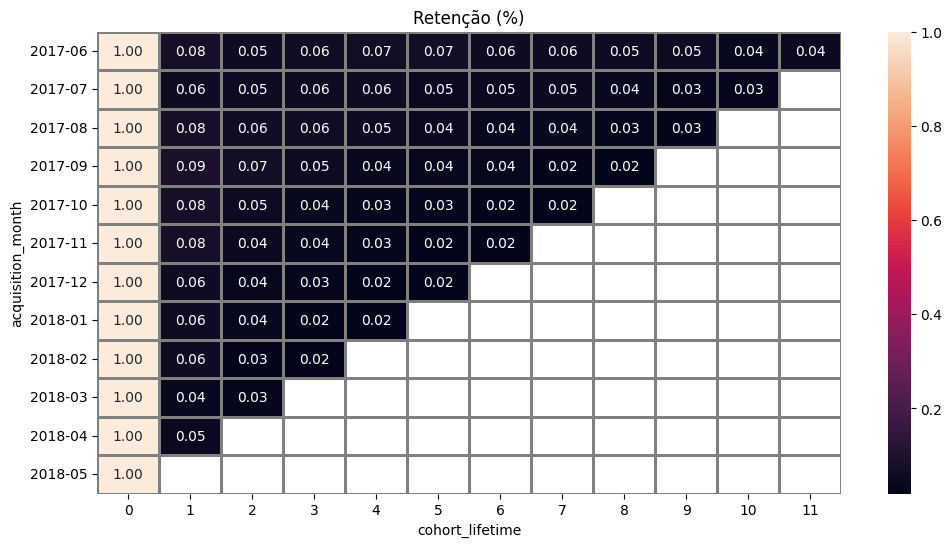

In [ ]:
# gerando o mapa de calor de retenção
plt.figure(figsize=(12,6))
plt.title('Retenção (%)')
sns.heatmap(
    data=retention_matrix,
    annot=True,
    fmt='.2f',
    linewidths=1,
    linecolor='gray'
    )

### 3.2 - Vendas

#### 3.2.1 - Quando as pessoas começam a comprar?

In [ ]:
# descoberta data primeira compra por usuário
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()

# renomeando colunas
first_order.columns = ['uid', 'first_order']

# criação coluna first_buy df orders
orders = pd.merge(orders, first_order, on='uid')

# criação df com dados de primeira compra/visita
conversion = pd.merge(first_order, first_visit, on='uid')

# ajuste tipo de dado
conversion['first_visit'] = pd.to_datetime(conversion['first_visit'])

# diferença entre data primeira compra/primeira visita
conversion['conversion_days'] = (conversion['first_order'] - conversion['first_visit']).dt.days

# descoberta média entre todos os usuários
print(f'O tempo médio para data de primeira compra é de cerca de {conversion['conversion_days'].mean():.1f} dias')
print(f'O tempo mediano para data de primeira compra é de cerca de {conversion['conversion_days'].median():.1f} dias')

O tempo médio para data de primeira compra é de cerca de 16.9 dias
O tempo mediano para data de primeira compra é de cerca de 0.0 dias


Os clientes levam em média 17 dias entre a data de registro e a primeira compra, enquanto a mediana é 0.

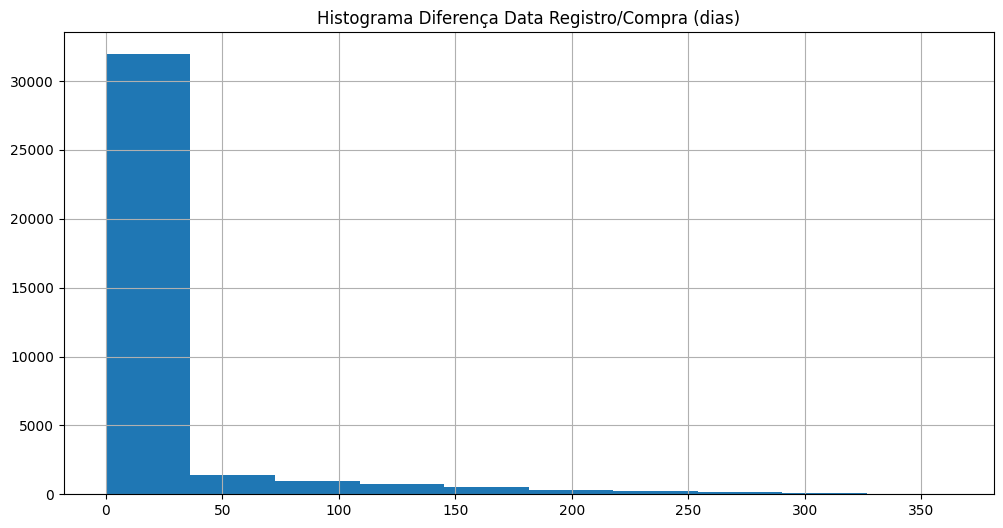

In [ ]:
# criação gráfico
plt.figure(figsize=(12,6))
plt.title('Histograma Diferença Data Registro/Compra (dias)')
conversion['conversion_days'].hist()
plt.show()

#### 3.2.2 - Quantos pedidos os clientes fazem durante um determinado período de tempo?

In [ ]:
# agrupamento do número de pedidos por períodos de tempo e descoberta média
daily_orders = orders.groupby('order_date').agg({'uid': 'count'}).reset_index()
weekly_orders = orders.groupby(['order_year', 'order_month', 'order_week']).agg({'uid': 'count'}).reset_index()
monthly_orders = orders.groupby(['order_year', 'order_month']).agg({'uid': 'count'}).reset_index()

print(f'O número médio de pedidos diários é de {daily_orders['uid'].mean():.1f}')
print(f'O número médio de pedidos semanais é de {weekly_orders['uid'].mean():.1f}')
print(f'O número médio de pedidos mensais é de {monthly_orders['uid'].mean():.1f}')

O número médio de pedidos diários é de 138.5
O número médio de pedidos semanais é de 800.2
O número médio de pedidos mensais é de 3878.1


A média de pedidos diários é de aproximadamente 138.

A média de pedidos semanais é de aproximadamente 800.

A média de pedidos mensais é de aproximadamente 3878.


In [ ]:
# criando coluna com o mês da primeira compra de cada cliente
orders['first_order_month'] = orders['first_order'].dt.to_period('M')

In [ ]:
# criação novo df cohort
orders_with_cohort = orders.copy()

In [ ]:
# mês de cada pedido
orders_with_cohort['order_month'] = orders_with_cohort['buy_ts'].dt.to_period('M')

In [ ]:
# calculando 'idade' do coorte para cada pedido (em meses desde a 1ª compra)
orders_with_cohort['cohort_age'] = (orders_with_cohort['order_month'] - orders_with_cohort['first_order_month']).apply(lambda x: x.n)
orders_with_cohort

,buy_ts,revenue,uid,order_date,order_week,order_month,order_year,first_order,first_order_month,cohort_age
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,22,2017-06,2017,2017-06-01 00:10:00,2017-06,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,22,2017-06,2017,2017-06-01 00:25:00,2017-06,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,22,2017-06,2017,2017-06-01 00:27:00,2017-06,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,22,2017-06,2017,2017-06-01 00:29:00,2017-06,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,22,2017-06,2017,2017-06-01 07:58:00,2017-06,0
...,...,...,...,...,...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31,22,2018-05,2018,2018-05-31 23:50:00,2018-05,0
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31,22,2018-05,2018,2018-05-31 23:50:00,2018-05,0
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31,22,2018-05,2018,2018-05-31 23:54:00,2018-05,0
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31,22,2018-05,2018,2018-05-31 23:56:00,2018-05,0


In [ ]:
# criando uma tabela pivot com o número total de pedidos por coorte e por idade
orders_by_cohort = orders_with_cohort.pivot_table(
 index='first_order_month',
 columns='cohort_age',
 values='uid',
 aggfunc='count'
 )
orders_by_cohort

cohort_age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,2354.0,177.0,174.0,226.0,292.0,218.0,276.0,174.0,212.0,153.0,96.0,86.0
2017-07,2186.0,100.0,120.0,104.0,72.0,82.0,61.0,50.0,58.0,24.0,53.0,NaN
2017-08,1533.0,108.0,100.0,81.0,85.0,62.0,49.0,78.0,46.0,46.0,NaN,NaN
2017-09,2933.0,219.0,161.0,164.0,67.0,109.0,108.0,56.0,61.0,NaN,NaN,NaN
2017-10,4964.0,314.0,162.0,122.0,129.0,103.0,86.0,125.0,NaN,NaN,NaN,NaN
2017-11,4813.0,397.0,182.0,211.0,136.0,59.0,102.0,NaN,NaN,NaN,NaN,NaN
2017-12,5052.0,270.0,202.0,179.0,86.0,105.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,3783.0,224.0,159.0,64.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4095.0,222.0,83.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# obtendo o tamanho de cada coorte (número de clientes únicos que compraram pela 1ª vez em cada mês)
cohort_size = orders_with_cohort.groupby('first_order_month')['uid'].nunique()
cohort_size

,uid
first_order_month,
2017-06,2023
2017-07,1923
2017-08,1370
2017-09,2581
2017-10,4340
2017-11,4081
2017-12,4383
2018-01,3373
2018-02,3651


In [ ]:
# dividindo o número de pedidos pelo tamanho do coorte para obter a média
avg_orders_pivot = orders_by_cohort.divide(cohort_size, axis=0)
avg_orders_pivot

cohort_age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,1.163618,0.087494,0.086011,0.111715,0.144340,0.107761,0.136431,0.086011,0.104795,0.075630,0.047454,0.042511
2017-07,1.136765,0.052002,0.062402,0.054082,0.037441,0.042642,0.031721,0.026001,0.030161,0.012480,0.027561,NaN
2017-08,1.118978,0.078832,0.072993,0.059124,0.062044,0.045255,0.035766,0.056934,0.033577,0.033577,NaN,NaN
2017-09,1.136381,0.084851,0.062379,0.063541,0.025959,0.042232,0.041844,0.021697,0.023634,NaN,NaN,NaN
2017-10,1.143779,0.072350,0.037327,0.028111,0.029724,0.023733,0.019816,0.028802,NaN,NaN,NaN,NaN
2017-11,1.179368,0.097280,0.044597,0.051703,0.033325,0.014457,0.024994,NaN,NaN,NaN,NaN,NaN
2017-12,1.152635,0.061602,0.046087,0.040840,0.019621,0.023956,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,1.121554,0.066410,0.047139,0.018974,0.023125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,1.121611,0.060805,0.022733,0.019173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


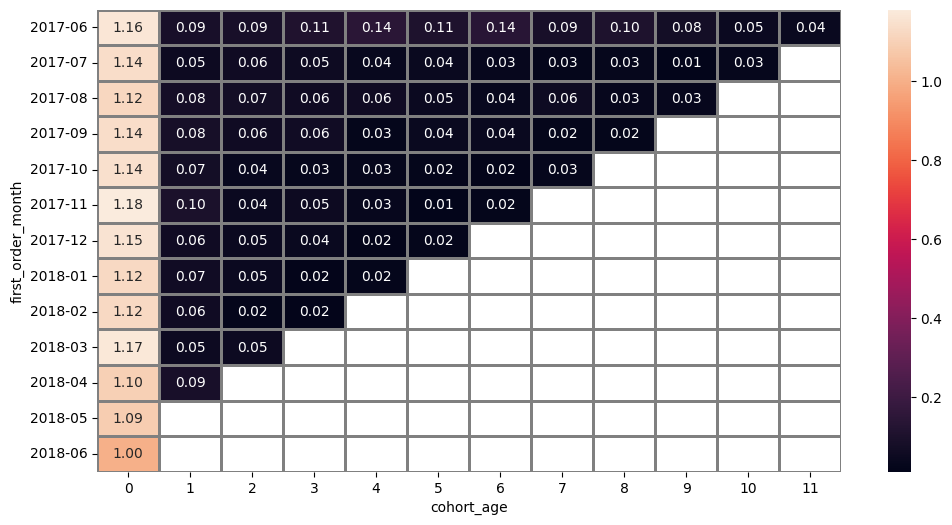

In [ ]:
# criação heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    avg_orders_pivot,
    annot=True,
    fmt='.2f',
    linewidths=1,
    linecolor='gray'
)
plt.show()

#### 3.2.3 - Qual é o volume médio de uma compra?

In [ ]:
# descoberta receita média por pedido
average_revenue = orders['revenue'].mean()
print(f"O ticket médio geral é: ${average_revenue:.2f}")

O ticket médio geral é: $5.00


O volume médio geral de uma compra é de cerca de $5.

In [ ]:
# análise do ticket médio ao longo do tempo
# orders['order_month'] = orders['buy_ts'].dt.to_period('M')
monthly_avg_revenue = orders.groupby(orders['buy_ts'].dt.to_period('M').dt.to_timestamp())['revenue'].mean().reset_index()

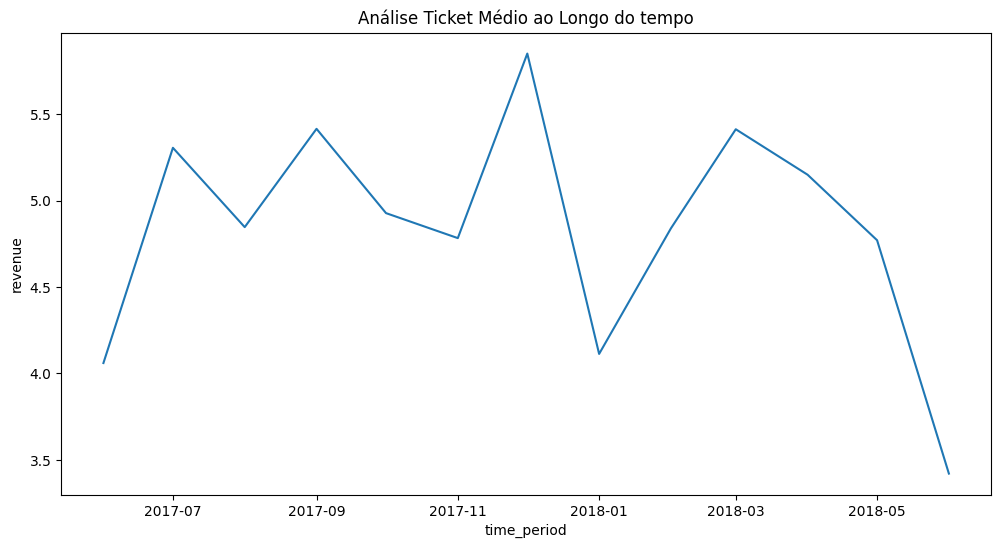

In [ ]:
# criação gráfico
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_avg_revenue, x='buy_ts', y='revenue')
plt.title('Análise Ticket Médio ao Longo do tempo')
plt.xlabel('time_period')
plt.show()

#### 3.2.4 - Quanto dinheiro eles trazem para a empresa (LTV)?

In [ ]:
# ajuste order_month
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

In [ ]:
# calculando a idade do coorte para cada pedido
orders['cohort_lifetime'] = ((orders['order_month'] - orders['first_order_month']).apply(lambda x: x.n))

In [ ]:
# calculando a receita por coorte e por idade
cohorts_revenue = orders.groupby(['first_order_month', 'cohort_lifetime'])['revenue'].sum().reset_index()
cohorts_revenue

,first_order_month,cohort_lifetime,revenue
0,2017-06,0,9557.49
1,2017-06,1,981.82
2,2017-06,2,885.34
3,2017-06,3,1931.30
4,2017-06,4,2068.58
...,...,...,...
74,2018-03,2,1114.87
75,2018-04,0,10600.69
76,2018-04,1,1209.92
77,2018-05,0,13925.76


In [ ]:
# obtendo o tamanho de cada coorte (número de clientes únicos)
cohort_sizes = orders.groupby('first_order_month')['uid'].nunique().reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']
cohort_sizes

,first_order_month,n_buyers
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340
5,2017-11,4081
6,2017-12,4383
7,2018-01,3373
8,2018-02,3651
9,2018-03,3533


In [ ]:
# unindo os dados de receita e tamanho do coorte
cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='first_order_month')
cohorts_data

,first_order_month,cohort_lifetime,revenue,n_buyers
0,2017-06,0,9557.49,2023
1,2017-06,1,981.82,2023
2,2017-06,2,885.34,2023
3,2017-06,3,1931.30,2023
4,2017-06,4,2068.58,2023
...,...,...,...,...
74,2018-03,2,1114.87,3533
75,2018-04,0,10600.69,2276
76,2018-04,1,1209.92,2276
77,2018-05,0,13925.76,2988


In [ ]:
# coluna LTV
cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']
cohorts_data

,first_order_month,cohort_lifetime,revenue,n_buyers,ltv
0,2017-06,0,9557.49,2023,4.724414
1,2017-06,1,981.82,2023,0.485329
2,2017-06,2,885.34,2023,0.437637
3,2017-06,3,1931.30,2023,0.954671
4,2017-06,4,2068.58,2023,1.022531
...,...,...,...,...,...
74,2018-03,2,1114.87,3533,0.315559
75,2018-04,0,10600.69,2276,4.657597
76,2018-04,1,1209.92,2276,0.531599
77,2018-05,0,13925.76,2988,4.660562


In [ ]:
# tabela pivot para o LTV
ltv_pivot = cohorts_data.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='ltv',
    aggfunc='sum').cumsum(axis=1)
ltv_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.724414,5.209743,5.647380,6.602051,7.624582,8.360084,9.310524,9.892116,10.445329,11.051117,11.622378,11.879234
2017-07,6.010218,6.345429,6.968960,7.327936,7.504727,7.660775,7.780983,7.922803,8.084035,8.231180,8.386854,NaN
2017-08,5.276518,5.748511,6.206993,6.598270,7.092321,7.375861,7.586526,7.991533,8.283745,8.471723,NaN,NaN
2017-09,5.644529,6.762115,7.283045,11.258838,11.659396,12.306463,13.008071,13.251220,13.435227,NaN,NaN,NaN
2017-10,5.003733,5.539495,5.730889,5.888035,6.039594,6.159956,6.244772,6.360242,NaN,NaN,NaN,NaN
2017-11,5.154683,5.553916,5.753472,6.078424,6.226437,6.280316,6.395244,NaN,NaN,NaN,NaN,NaN
2017-12,4.738191,4.998565,5.923662,6.988937,7.301866,7.639913,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,4.135636,4.430394,4.734675,4.877453,4.940151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4.156987,4.435262,4.513777,4.587921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'LTV')

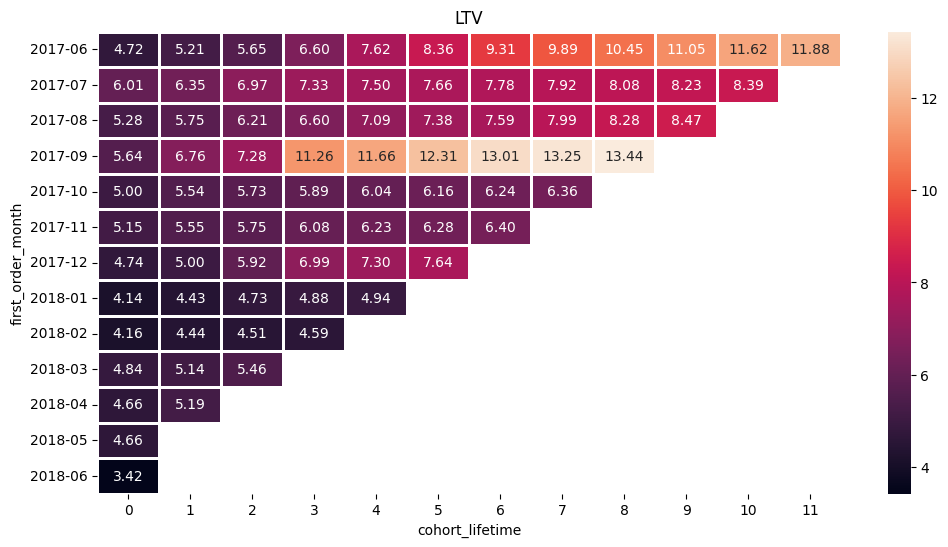

In [ ]:
# heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    ltv_pivot,
    annot=True,
    fmt='.2f',
    linewidths=1,
    color='gray'
)
plt.title('LTV')

Cada cliente da primeira coorte trouxe $11.88 de receita ao longo de seu tempo de vida de doze meses.

## 3.3 - Marketing

#### 3.3.1 - Quanto dinheiro foi gasto?

In [ ]:
# descoberta valor total gastos com marketing
total_costs = costs['costs'].sum()

# agregando custo somado diário e descobrindo média geral
costs_per_day = costs.groupby(['year', 'month', 'week', 'dt'])['costs'].sum().reset_index()

# agregando custo somado semanaç e descobrindo média geral
costs_per_week = costs.groupby(['year', 'month', 'week'])['costs'].sum().reset_index()

# agregando custo somado mensal e descobrindo média geral
costs_per_month = costs.groupby(['year', 'month'])['costs'].sum().reset_index()

print(f'A soma de gastos gerais com marketing foi de cerca de ${total_costs:.2f}.')
print(f'A média geral de gastos diários com marketing foi de cerca ${costs_per_day['costs'].mean():.2f}.')
print(f'A média geral de gastos semanais com marketing foi de cerca ${costs_per_week['costs'].mean():.2f}.')
print(f'A média geral de gastos mensais com marketing foi de cerca ${costs_per_month['costs'].mean():.2f}.')

A soma de gastos gerais com marketing foi de cerca de $329131.62.
A média geral de gastos diários com marketing foi de cerca $904.21.
A média geral de gastos semanais com marketing foi de cerca $5308.57.
A média geral de gastos mensais com marketing foi de cerca $27427.63.


Em média, foram gastos com marketing por dia cerca de $904.
Por semana, cerca de $5308.
Por mês, cerca de $27428.

No geral, cerca de $329131.

In [ ]:
# ajuste coluna month
costs['month'] = costs['dt'].dt.to_period('M')

In [ ]:
# criação objeto para plotar
costs_plot = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()

# ajuste dado
costs_plot['month'] = costs_plot['month'].dt.to_timestamp()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   month      84 non-null     datetime64[ns]
 1   source_id  84 non-null     category      
 2   costs      84 non-null     float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 1.9 KB


/tmp/ipython-input-472821382.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  costs_plot = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()


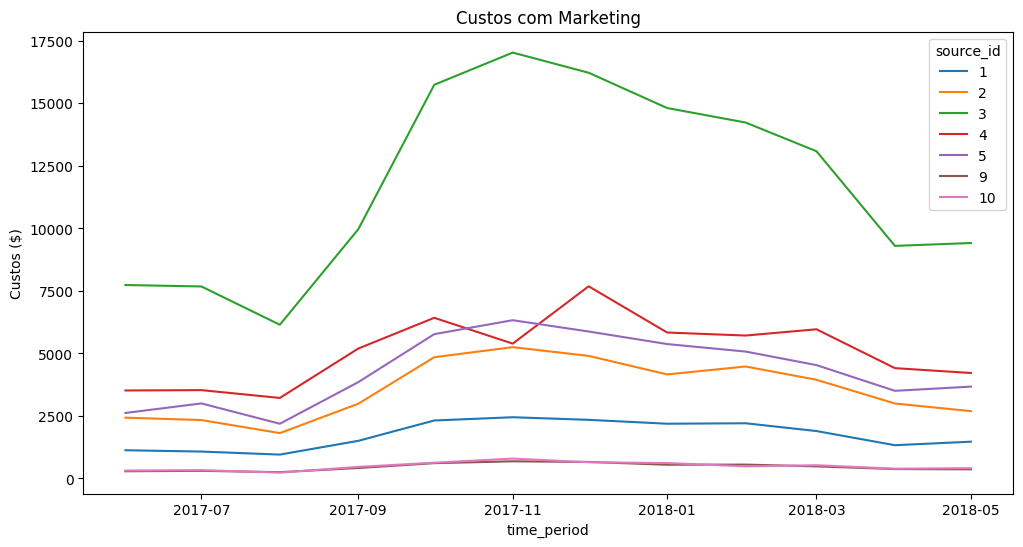

In [ ]:
# criação gráfico
plt.figure(figsize=(12,6))
sns.lineplot(data=costs_plot, x='month', y='costs', hue='source_id')
plt.title('Custos com Marketing')
plt.ylabel('Custos ($)')
plt.xlabel('time_period')
plt.show()

#### 3.3.2 - Quanto custou a aquisição de clientes para cada origem?

In [ ]:
cost_by_source = costs.groupby('source_id').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)
cost_by_source

/tmp/ipython-input-3839097954.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_by_source = costs.groupby('source_id').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)


,source_id,costs
2,3,141321.63
3,4,61073.60
4,5,51757.10
1,2,42806.04
0,1,20833.27
6,10,5822.49
5,9,5517.49


A fonte mais custosa de clientes foi source_id 3 com alguma vantagem, seguida por source_id 4, 5 e 2.

In [ ]:
# encontrando a primeira visita de cada usuário para obter a fonte de aquisição
first_visits = visits.sort_values('start_ts').drop_duplicates('uid')
first_visits = first_visits[['uid', 'source_id']]

In [ ]:
# encontrando o mês da primeira compra de cada cliente
first_orders = orders.sort_values('buy_ts').drop_duplicates('uid')
first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')
first_orders = first_orders[['uid', 'acquisition_month']]

In [ ]:
# unindo as informações para saber a fonte e o mês de aquisição de cada cliente
buyers = pd.merge(first_orders, first_visits, on='uid')

In [ ]:
# calculando o número de clientes adquiridos por mês e por fonte
buyers_by_month_source = buyers.groupby(['acquisition_month', 'source_id'])['uid'].nunique().reset_index()
buyers_by_month_source.columns = ['month', 'source_id', 'n_buyers']

/tmp/ipython-input-2723461614.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buyers_by_month_source = buyers.groupby(['acquisition_month', 'source_id'])['uid'].nunique().reset_index()


In [ ]:
# formanto os custos mensais por fonte
costs_by_month_source = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()

/tmp/ipython-input-283460657.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  costs_by_month_source = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()


In [ ]:
# unindo custos e número de compradores por mês e fonte
cac_monthly_data = pd.merge(costs_by_month_source, buyers_by_month_source, on=['month', 'source_id'])

In [ ]:
# CAC mensal para cada fonte
cac_monthly_data = cac_monthly_data[cac_monthly_data['n_buyers'] > 0]
cac_monthly_data['cac'] = cac_monthly_data['costs'] / cac_monthly_data['n_buyers']

In [ ]:
# tabela dinâmica para a plotagem
cac_monthly_data['month'] = cac_monthly_data['month'].dt.to_timestamp()

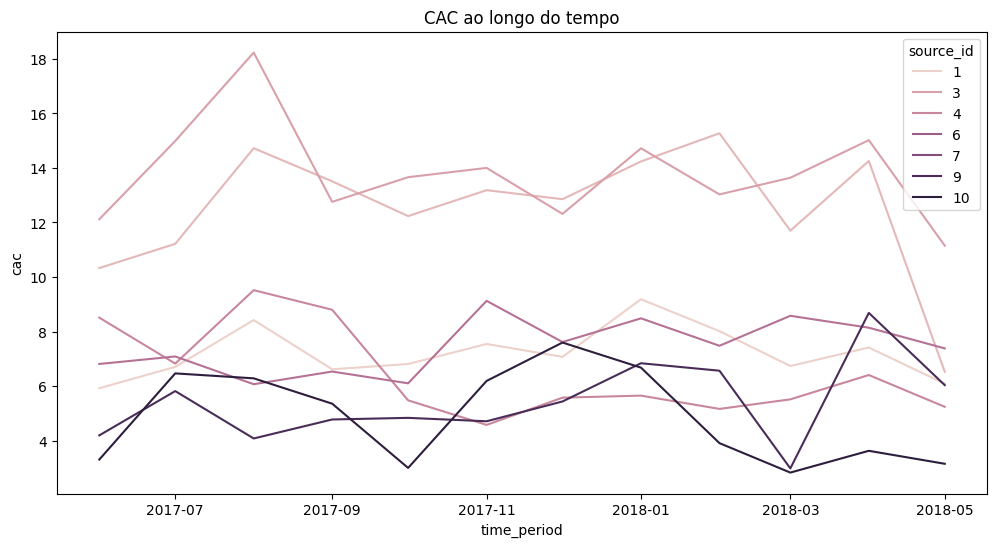

In [ ]:
# gráfico de linhas
plt.figure(figsize=(12,6))
sns.lineplot(data=cac_monthly_data, x='month', y='cac', hue='source_id')
plt.title('CAC ao longo do tempo')
plt.xlabel('time_period')
plt.show()

#### 3.3.3 - Os investimentos valeram a pena?

In [ ]:
# descoberta receita total
total_revenue = orders['revenue'].sum()

# cálculo romi
romi = (total_revenue - total_costs) / total_costs
romi

np.float64(-0.2341750695360112)

Os investimentos não valeram a pena, logo que o ROMI foi de cerca de -23%.

In [ ]:
# LTV acumulado por coorte
ltv_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.724414,5.209743,5.647380,6.602051,7.624582,8.360084,9.310524,9.892116,10.445329,11.051117,11.622378,11.879234
2017-07,6.010218,6.345429,6.968960,7.327936,7.504727,7.660775,7.780983,7.922803,8.084035,8.231180,8.386854,NaN
2017-08,5.276518,5.748511,6.206993,6.598270,7.092321,7.375861,7.586526,7.991533,8.283745,8.471723,NaN,NaN
2017-09,5.644529,6.762115,7.283045,11.258838,11.659396,12.306463,13.008071,13.251220,13.435227,NaN,NaN,NaN
2017-10,5.003733,5.539495,5.730889,5.888035,6.039594,6.159956,6.244772,6.360242,NaN,NaN,NaN,NaN
2017-11,5.154683,5.553916,5.753472,6.078424,6.226437,6.280316,6.395244,NaN,NaN,NaN,NaN,NaN
2017-12,4.738191,4.998565,5.923662,6.988937,7.301866,7.639913,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,4.135636,4.430394,4.734675,4.877453,4.940151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4.156987,4.435262,4.513777,4.587921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
first_orders = first_orders.rename(columns={'acquisition_month': 'first_order_month'})

In [ ]:
# CAC por coorte (mês de aquisição)
n_buyers_by_cohort = first_orders.groupby('first_order_month')['uid'].nunique().reset_index()
n_buyers_by_cohort.columns = ['month', 'n_buyers']
costs_by_cohort = costs.groupby('month')['costs'].sum().reset_index()
cac_by_cohort = pd.merge(costs_by_cohort, n_buyers_by_cohort, on='month')
cac_by_cohort['cac'] = cac_by_cohort['costs'] / cac_by_cohort['n_buyers']
cac_by_cohort = cac_by_cohort[['month', 'cac']]
cac_by_cohort.columns = ['first_order_month', 'cac']

In [ ]:
# ROMI (LTV - CAC) / CAC
report = pd.merge(ltv_pivot.reset_index(), cac_by_cohort, on='first_order_month')
report = report.set_index('first_order_month')

In [ ]:
# obtendo a coluna de CAC e as colunas de LTV
cac_values = report['cac']
ltv_values = report.drop(columns=['cac'])

In [ ]:
# calculando o ROMI para cada mês da vida do coorte
romi_pivot = ltv_values.subtract(cac_values, axis=0).divide(cac_values, axis=0)

Text(0.5, 1.0, 'ROMI ao longo do tempo')

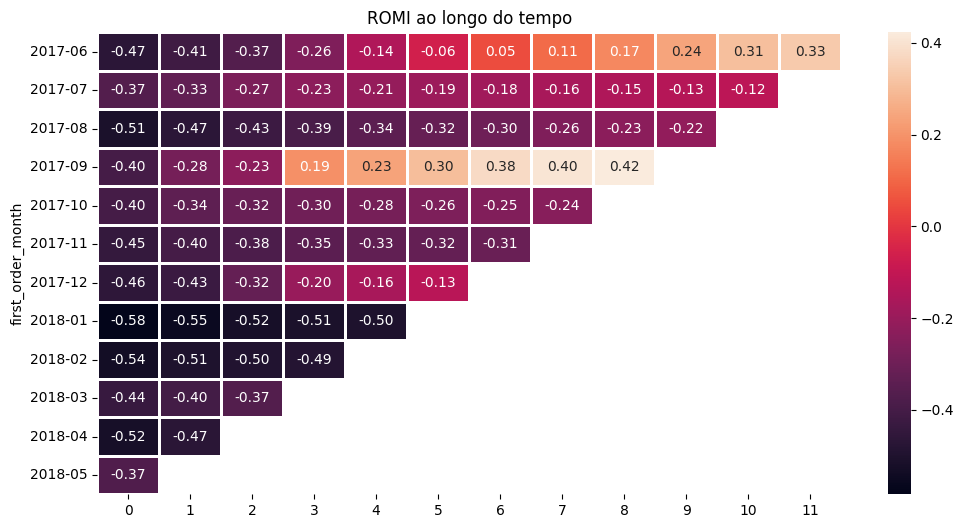

In [ ]:
# heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    romi_pivot,
    annot=True,
    fmt='.2f',
    linewidths=1,
    color='gray'
    )
plt.title('ROMI ao longo do tempo')

# 4. - Conclusão

### 4.1 - Análise rentabilidade fontes

In [ ]:
# ordenação visitas por usuário e data
visits_sorted = visits.sort_values(['uid', 'start_ts'])

# seleção apenas a primeira visita de cada usuário
visits_sorted = visits_sorted.drop_duplicates(subset='uid', keep='first')

In [ ]:
# junção orders com a fonte da primeira visita
orders_with_source = orders.merge(
    visits_sorted[['uid', 'source_id']],
    on='uid',
    how='left')

# receita por source_id
revenue_by_source = orders_with_source.groupby('source_id')['revenue'].sum().reset_index()
revenue_by_source = revenue_by_source.rename(columns={'revenue': 'total_revenue'})
revenue_by_source

/tmp/ipython-input-1021554553.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_source = orders_with_source.groupby('source_id')['revenue'].sum().reset_index()


,source_id,total_revenue
0,1,31090.55
1,2,46923.61
2,3,54511.24
3,4,56696.83
4,5,52624.02
5,6,0.00
6,7,1.22
7,9,5759.40
8,10,4450.33


In [ ]:
# renomeando coluna
cost_by_source = cost_by_source.rename(columns={'costs': 'total_cost'})

# novo df com receitas e despesas totais por fonte
sources = pd.merge(revenue_by_source, cost_by_source, on='source_id')

# criação coluna lucro bruto
sources['gross_profit'] = sources['total_revenue'] - sources['total_cost']
sources

,source_id,total_revenue,total_cost,gross_profit
0,1,31090.55,20833.27,10257.28
1,2,46923.61,42806.04,4117.57
2,3,54511.24,141321.63,-86810.39
3,4,56696.83,61073.60,-4376.77
4,5,52624.02,51757.10,866.92
5,9,5759.40,5517.49,241.91
6,10,4450.33,5822.49,-1372.16


As fontes que representaram lucro foram id: 1, 2, 5 e 9.

As fontes que representaram maior prejuízo foram id: 3, 4 e 6.

### 4.2 - Análise rentabilidade dispositivos + fontes

In [ ]:
# junção orders com o dispositivo da primeira visita
orders_with_device = orders.merge(
    visits_sorted[['uid', 'device', 'source_id']],
    on='uid',
    how='left')
orders_with_device

,buy_ts,revenue,uid,order_date,order_week,order_month,order_year,first_order,first_order_month,cohort_lifetime,device,source_id
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,22,2017-06,2017,2017-06-01 00:10:00,2017-06,0,desktop,1
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,22,2017-06,2017,2017-06-01 00:25:00,2017-06,0,desktop,2
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,22,2017-06,2017,2017-06-01 00:27:00,2017-06,0,desktop,2
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,22,2017-06,2017,2017-06-01 00:29:00,2017-06,0,desktop,2
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,22,2017-06,2017,2017-06-01 07:58:00,2017-06,0,desktop,3
...,...,...,...,...,...,...,...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31,22,2018-05,2018,2018-05-31 23:50:00,2018-05,0,touch,4
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31,22,2018-05,2018,2018-05-31 23:50:00,2018-05,0,desktop,10
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31,22,2018-05,2018,2018-05-31 23:54:00,2018-05,0,desktop,3
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31,22,2018-05,2018,2018-05-31 23:56:00,2018-05,0,desktop,3


In [ ]:
# agrupamento fontes e dispositivos com soma de receita
revenue_by_source_device = orders_with_device.groupby(['source_id', 'device'])['revenue'].sum().reset_index()
revenue_by_source_device

/tmp/ipython-input-3365109149.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_source_device = orders_with_device.groupby(['source_id', 'device'])['revenue'].sum().reset_index()


,source_id,device,revenue
0,1,desktop,25995.60
1,1,touch,5094.95
2,2,desktop,40386.63
3,2,touch,6536.98
4,3,desktop,46273.75
5,3,touch,8237.49
6,4,desktop,43414.96
7,4,touch,13281.87
8,5,desktop,46825.34
9,5,touch,5798.68


In [ ]:
# receita total da source com receita por device
devices = revenue_by_source_device.merge(revenue_by_source, on='source_id', how='left')

# cálculo proporção da receita total por receita por dispositivo
devices['proportion'] = devices['revenue'] / devices['total_revenue']

# custo total da source
devices = devices.merge(cost_by_source, on='source_id', how='left')

# cálculo custo atribuído a cada device
devices['costs_device'] = devices['proportion'] * devices['total_cost']

# gross profit por device
devices['gross_profit'] = devices['revenue'] - devices['costs_device']
devices

,source_id,device,revenue,total_revenue,proportion,total_cost,costs_device,gross_profit
0,1,desktop,25995.60,31090.55,0.836125,20833.27,17419.227180,8576.372820
1,1,touch,5094.95,31090.55,0.163875,20833.27,3414.042820,1680.907180
2,2,desktop,40386.63,46923.61,0.860689,42806.04,36842.683230,3543.946770
3,2,touch,6536.98,46923.61,0.139311,42806.04,5963.356770,573.623230
4,3,desktop,46273.75,54511.24,0.848885,141321.63,119965.749747,-73691.999747
5,3,touch,8237.49,54511.24,0.151115,141321.63,21355.880253,-13118.390253
6,4,desktop,43414.96,56696.83,0.765739,61073.60,46766.422409,-3351.462409
7,4,touch,13281.87,56696.83,0.234261,61073.60,14307.177591,-1025.307591
8,5,desktop,46825.34,52624.02,0.889809,51757.10,46053.946561,771.393439
9,5,touch,5798.68,52624.02,0.110191,51757.10,5703.153439,95.526561


In [ ]:
# resultado final: device e suas métricas
result_by_device = devices.groupby('device')[['revenue', 'costs_device', 'gross_profit']].sum().reset_index()
result_by_device

/tmp/ipython-input-3258691079.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_by_device = devices.groupby('device')[['revenue', 'costs_device', 'gross_profit']].sum().reset_index()


,device,revenue,costs_device,gross_profit
0,desktop,211329.77,276375.350466,-65046.800466
1,touch,40727.43,52756.269534,-12028.839534


Ambos dispositivos deram prejuízo, com destaque ao desktop.

## 4.3 - Conclusões finais

Com base na análise de todos os arquivos de dados forncecidos pela Y.Afisha, como a primeira medida a se tomar para otimizar as despesas com marketing, deve-se urgentemente realocar todos os recursos destinados a fonte n3 para outras fontes de clientes, logo que está fonte apresenta a maior taxa de prejuízo. Opções mais viáveis seriam as fontes n1, n2, n5 e n9.
O mesmo vale para as fontes n3, n4 e n10, que apresentam saldo negativo.

Devem-se também focar os esforços comerciais na captação de clientes através do desktop, logo que apresentam taxas superiores se comparados ao touch.